# 2 · Run all five models — Kaggle

Tutorial **"The Science of Benchmarking — What's Measured, What's Missing, What's Next"** (NeurIPS 2025).

Two real benchmarks (**MMLU**, **GSM8K**) + **five small instruction models** (Gemma-4 E2B/E4B, Qwen3.5-4B, Phi-3.5-mini, Qwen2.5-3B) + non-LLM baselines, run through the tutorial's toolkit: saturation/scaling, baselines, metric brittleness, robustness, per-subject construct variance, extraction coverage, and ranking (in)stability across benchmarks.

### Kaggle setup (do this first)
1. **Settings → Accelerator → `GPU T4`** (single T4 is enough; `T4 x2` only adds headroom).
2. **Settings → Internet → On** (needed for pip + Hugging Face download).
3. **Add-ons → Secrets →** add a secret named **`HF_TOKEN`** (a HF *read* token). Accept the Gemma licence once at <https://huggingface.co/google/gemma-4-E4B-it> (the other models are ungated).
4. **Run → Run all.** Greedy decoding ⇒ deterministic ⇒ reproducible.

> The committed `results/predictions/*.json` cache makes already-scored models load instantly — add a model to `config.SYSTEMS` and re-run to score only the new one. Run `1_smoke_test.ipynb` first if you want to verify a new model loads.

## 1. Get the code + deps
Kaggle ships a CUDA build of `torch` already — do **not** reinstall it. We add only the missing libraries.

In [1]:
# Option A: clone from GitHub (replace URL with this repo).
# Option B: attach the repo as a Kaggle Dataset and skip the clone
#           (it will be under /kaggle/input/<dataset-name>/).
REPO_URL = "https://github.com/ThuongHong/science-of-benchmarking-demo.git"

import os, sys, subprocess
REPO_DIR = REPO_URL.rsplit("/", 1)[-1].removesuffix(".git")
WORK = f"/kaggle/working/{REPO_DIR}"
if not os.path.isdir(WORK):
    subprocess.run(["git", "clone", "--quiet", REPO_URL, WORK], check=True)
os.chdir(WORK)
sys.path.insert(0, "src")

# only the libs Kaggle doesn't already have; leave torch untouched
!pip install -q -U transformers accelerate bitsandbytes datasets sentencepiece
print("cwd:", os.getcwd())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 111.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numb

## 2. Hugging Face auth (via Kaggle Secret `HF_TOKEN`)

In [2]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
login(UserSecretsClient().get_secret("HF_TOKEN"))
print("HF login OK")

HF login OK


## 3. GPU check
Confirms the accelerator is visible. `device_map="auto"` (used by `HFRunner`) places each model on the GPU; one model is loaded at a time.

In [3]:
import torch
print("CUDA devices:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(" ", torch.cuda.get_device_name(i))

CUDA devices: 2
  Tesla T4
  Tesla T4


## 4. Build benchmark subsets (downloads MMLU + GSM8K once)

In [4]:
import config
from data import build_subsets
subs = build_subsets(config.N_MMLU, config.N_GSM8K, config.SEED)
print({k: len(v) for k, v in subs.items()})
subs["gsm8k"][0]

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

all/test-00000-of-00001.parquet:   0%|          | 0.00/3.50M [00:00<?, ?B/s]

all/validation-00000-of-00001.parquet:   0%|          | 0.00/408k [00:00<?, ?B/s]

all/dev-00000-of-00001.parquet:   0%|          | 0.00/76.5k [00:00<?, ?B/s]

...

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

{'mmlu': 150, 'gsm8k': 80}


{'id': 'gsm8k_0000',
 'benchmark': 'gsm8k',
 'question': 'John is raising money for a school trip. He has applied for help from the school, which has decided to cover half the cost of the trip. How much money is John missing if he has $50 and the trip costs $300?',
 'answer': '100',
 'solution': "John's school has decided to pay 300 / 2 = $<<300/2=150>>150 for his trip.\nIn total John has covered 150 + 50 = $<<150+50=200>>200 for his trip\nTherefore, John needs 300 - 200 = $<<300-200=100>>100 more for the trip."}

## 5. Systems under test
Five real models: a Gemma-4 scaling pair **E2B → E4B**, plus three ~3–4B cross-family peers **Qwen3.5-4B / Phi-3.5-mini / Qwen2.5-3B** (fixed-size panel for the ranking-stability test) — and `random` / `majority` baselines. All fit a single T4 in 4-bit.

In [5]:
systems = config.SYSTEMS   # 5 models (Gemma-4 E2B/E4B, Qwen3.5-4B, Phi-3.5-mini, Qwen2.5-3B) + baselines
[s.get("name", s.get("baseline")) for s in systems]

['gemma-4-e2b',
 'gemma-4-e4b',
 'qwen3.5-4b',
 'phi-3.5-mini',
 'qwen2.5-3b',
 'random',
 'majority']

## 6. Run the evaluation
First call downloads each model. Greedy generations are cached, so re-runs resume instantly.

In [6]:
import evaluate
df = evaluate.run(systems)
df.to_csv("results/per_item.csv", index=False)
print(len(df), "rows -> results/per_item.csv")
df.head()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[qwen2.5-3b] 280 items...
  qwen2.5-3b: 50/280
  qwen2.5-3b: 100/280
  qwen2.5-3b: 150/280
  qwen2.5-3b: 200/280
  qwen2.5-3b: 250/280
[baseline-random] 280 items...
  baseline-random: 50/280
  baseline-random: 100/280
  baseline-random: 150/280
  baseline-random: 200/280
  baseline-random: 250/280
[baseline-majority] 280 items...
  baseline-majority: 50/280
  baseline-majority: 100/280
  baseline-majority: 150/280
  baseline-majority: 200/280
  baseline-majority: 250/280
1960 rows -> results/per_item.csv


,system,benchmark,id,orig_id,perturbation,subject,gold,prediction,extracted,correct,correct_naive
0,gemma-4-e2b,mmlu,mmlu_0000,,,professional_psychology,D,C,C,0,0
1,gemma-4-e2b,mmlu,mmlu_0001,,,moral_scenarios,A,A,A,1,1
2,gemma-4-e2b,mmlu,mmlu_0002,,,clinical_knowledge,A,B,B,0,0
3,gemma-4-e2b,mmlu,mmlu_0003,,,high_school_microeconomics,A,B,B,0,0
4,gemma-4-e2b,mmlu,mmlu_0004,,,college_medicine,C,C,C,1,1


## 7. Analysis + figures

In [7]:
import analysis
analysis.main()

=== Accuracy (MMLU vs GSM8K) ===
           system  acc_gsm8k  acc_mmlu  params_b  is_baseline
       qwen3.5-4b     0.9125  0.686667       4.0        False
     phi-3.5-mini     0.8500  0.586667       3.8        False
      gemma-4-e4b     0.7875  0.533333       4.5        False
       qwen2.5-3b     0.7750  0.513333       3.1        False
      gemma-4-e2b     0.7250  0.426667       2.3        False
baseline-majority     0.0000  0.253333       NaN         True
  baseline-random     0.0500  0.233333       NaN         True

=== GSM8K metric gap (first-number vs last-number) ===
      system  acc_naive  acc_robust  n_robust_only  n
  qwen3.5-4b     0.0125      0.9125             72 80
phi-3.5-mini     0.0125      0.8500             67 80
 gemma-4-e4b     0.0000      0.7875             63 80
  qwen2.5-3b     0.0125      0.7750             62 80
 gemma-4-e2b     0.0000      0.7250             58 80

=== MMLU robustness (original vs perturbed) ===
      system  acc_original  acc_perturbed 

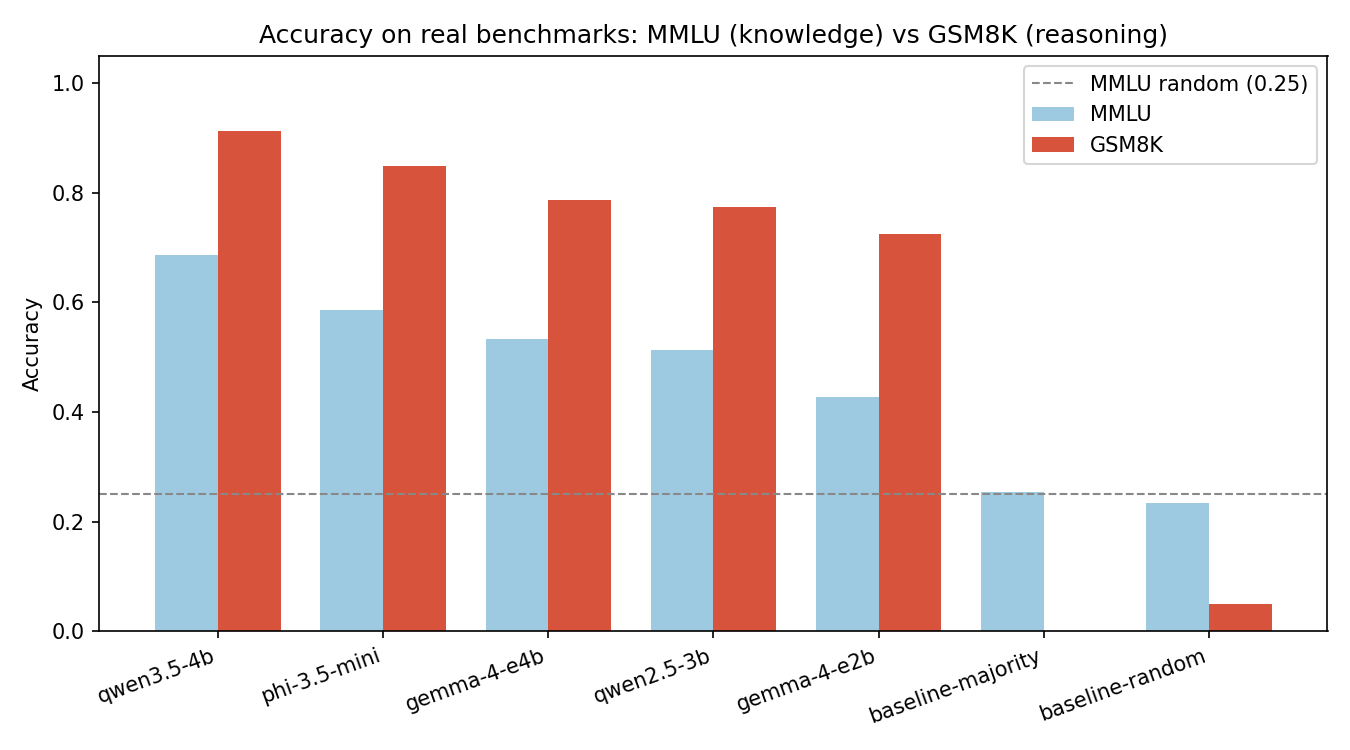

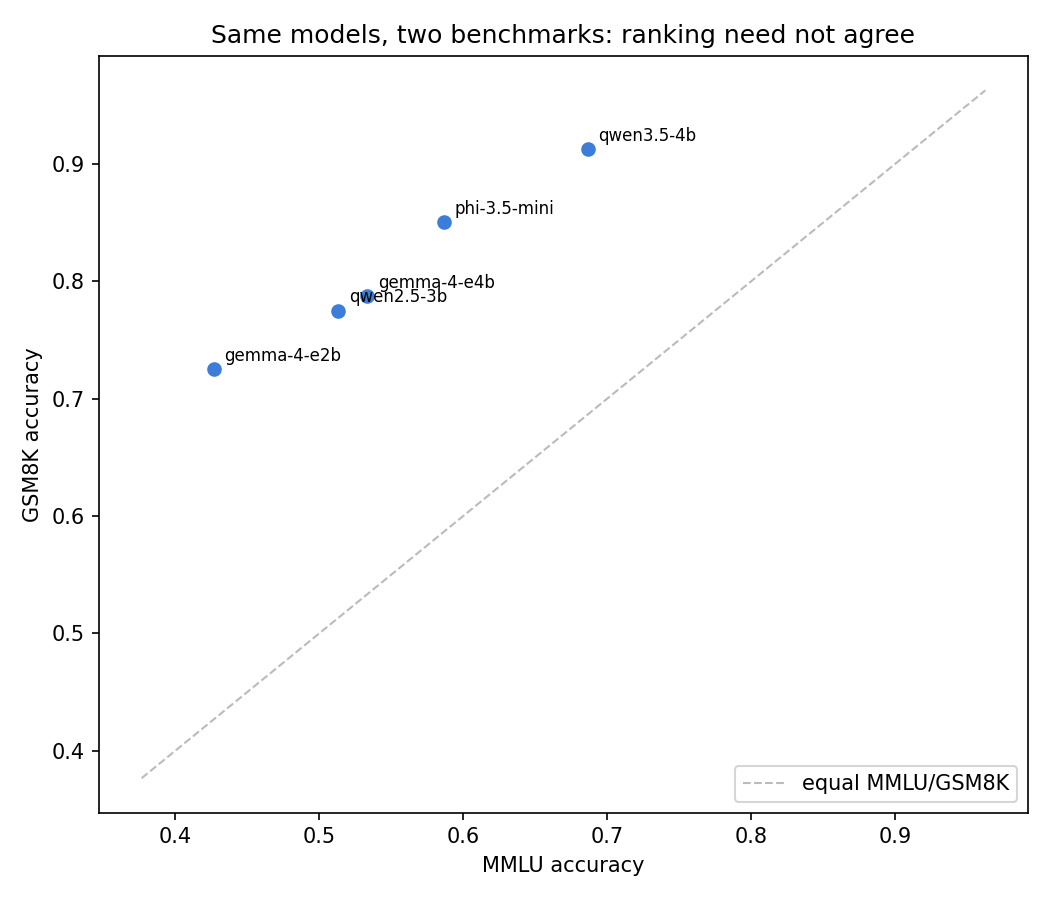

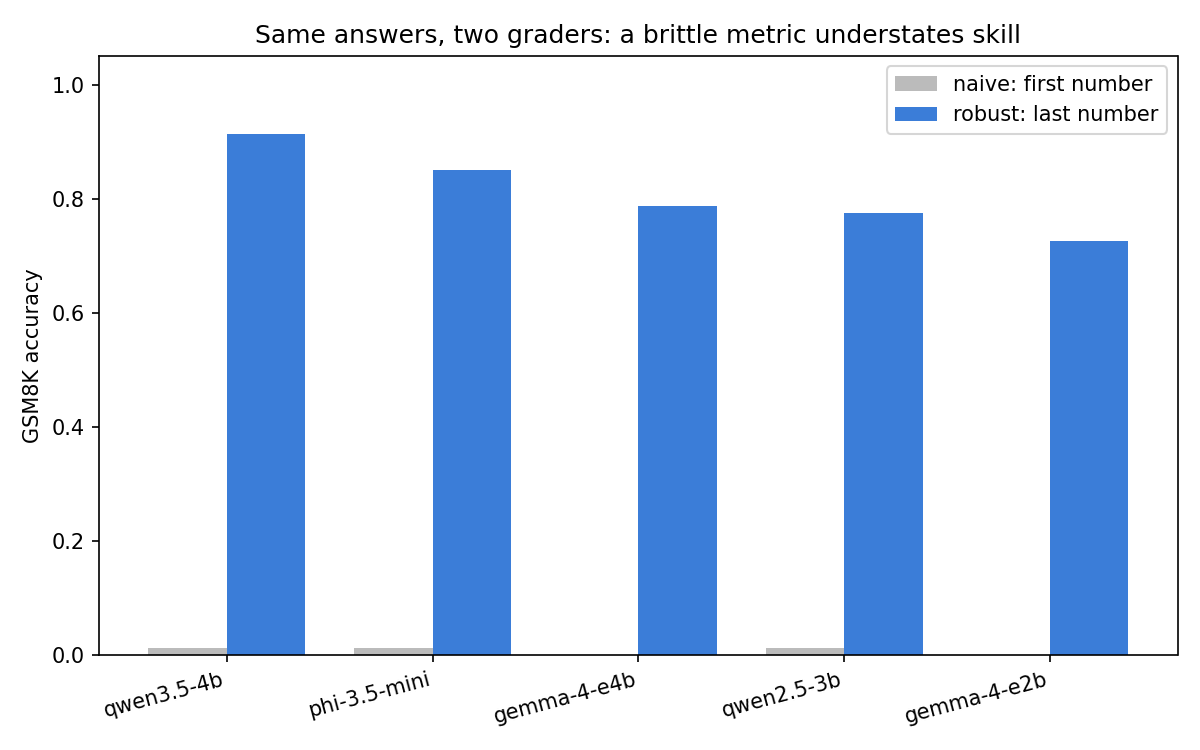

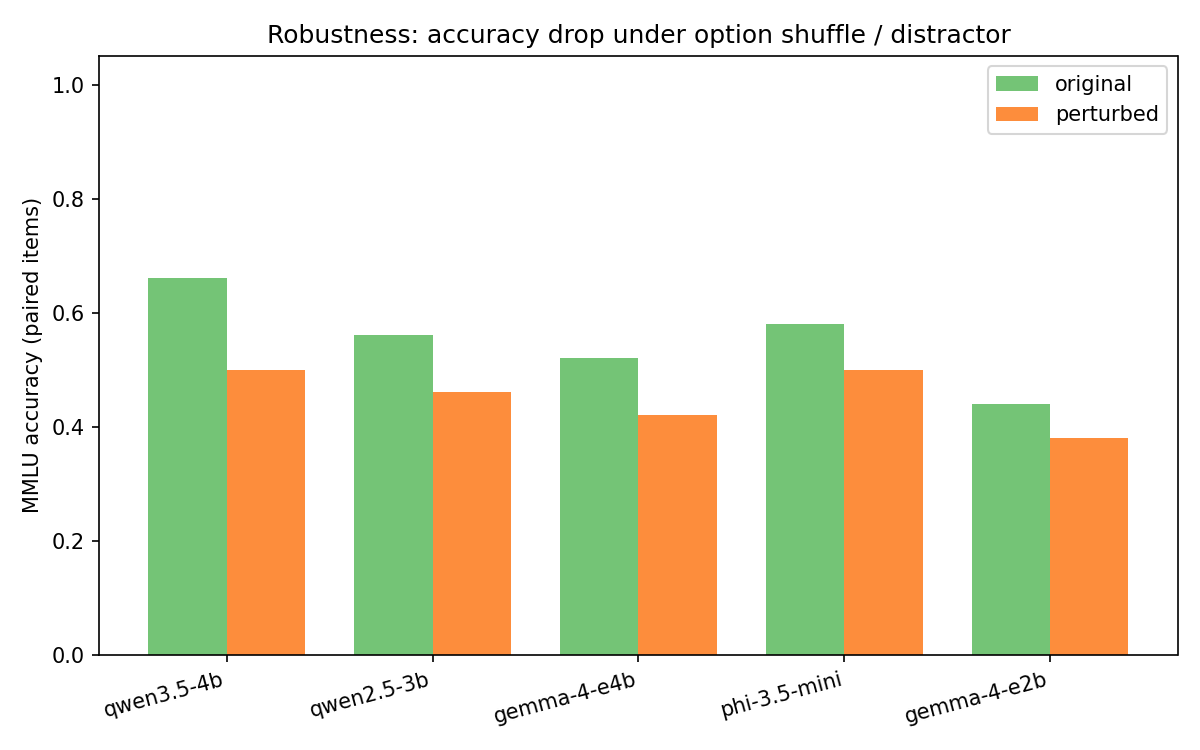

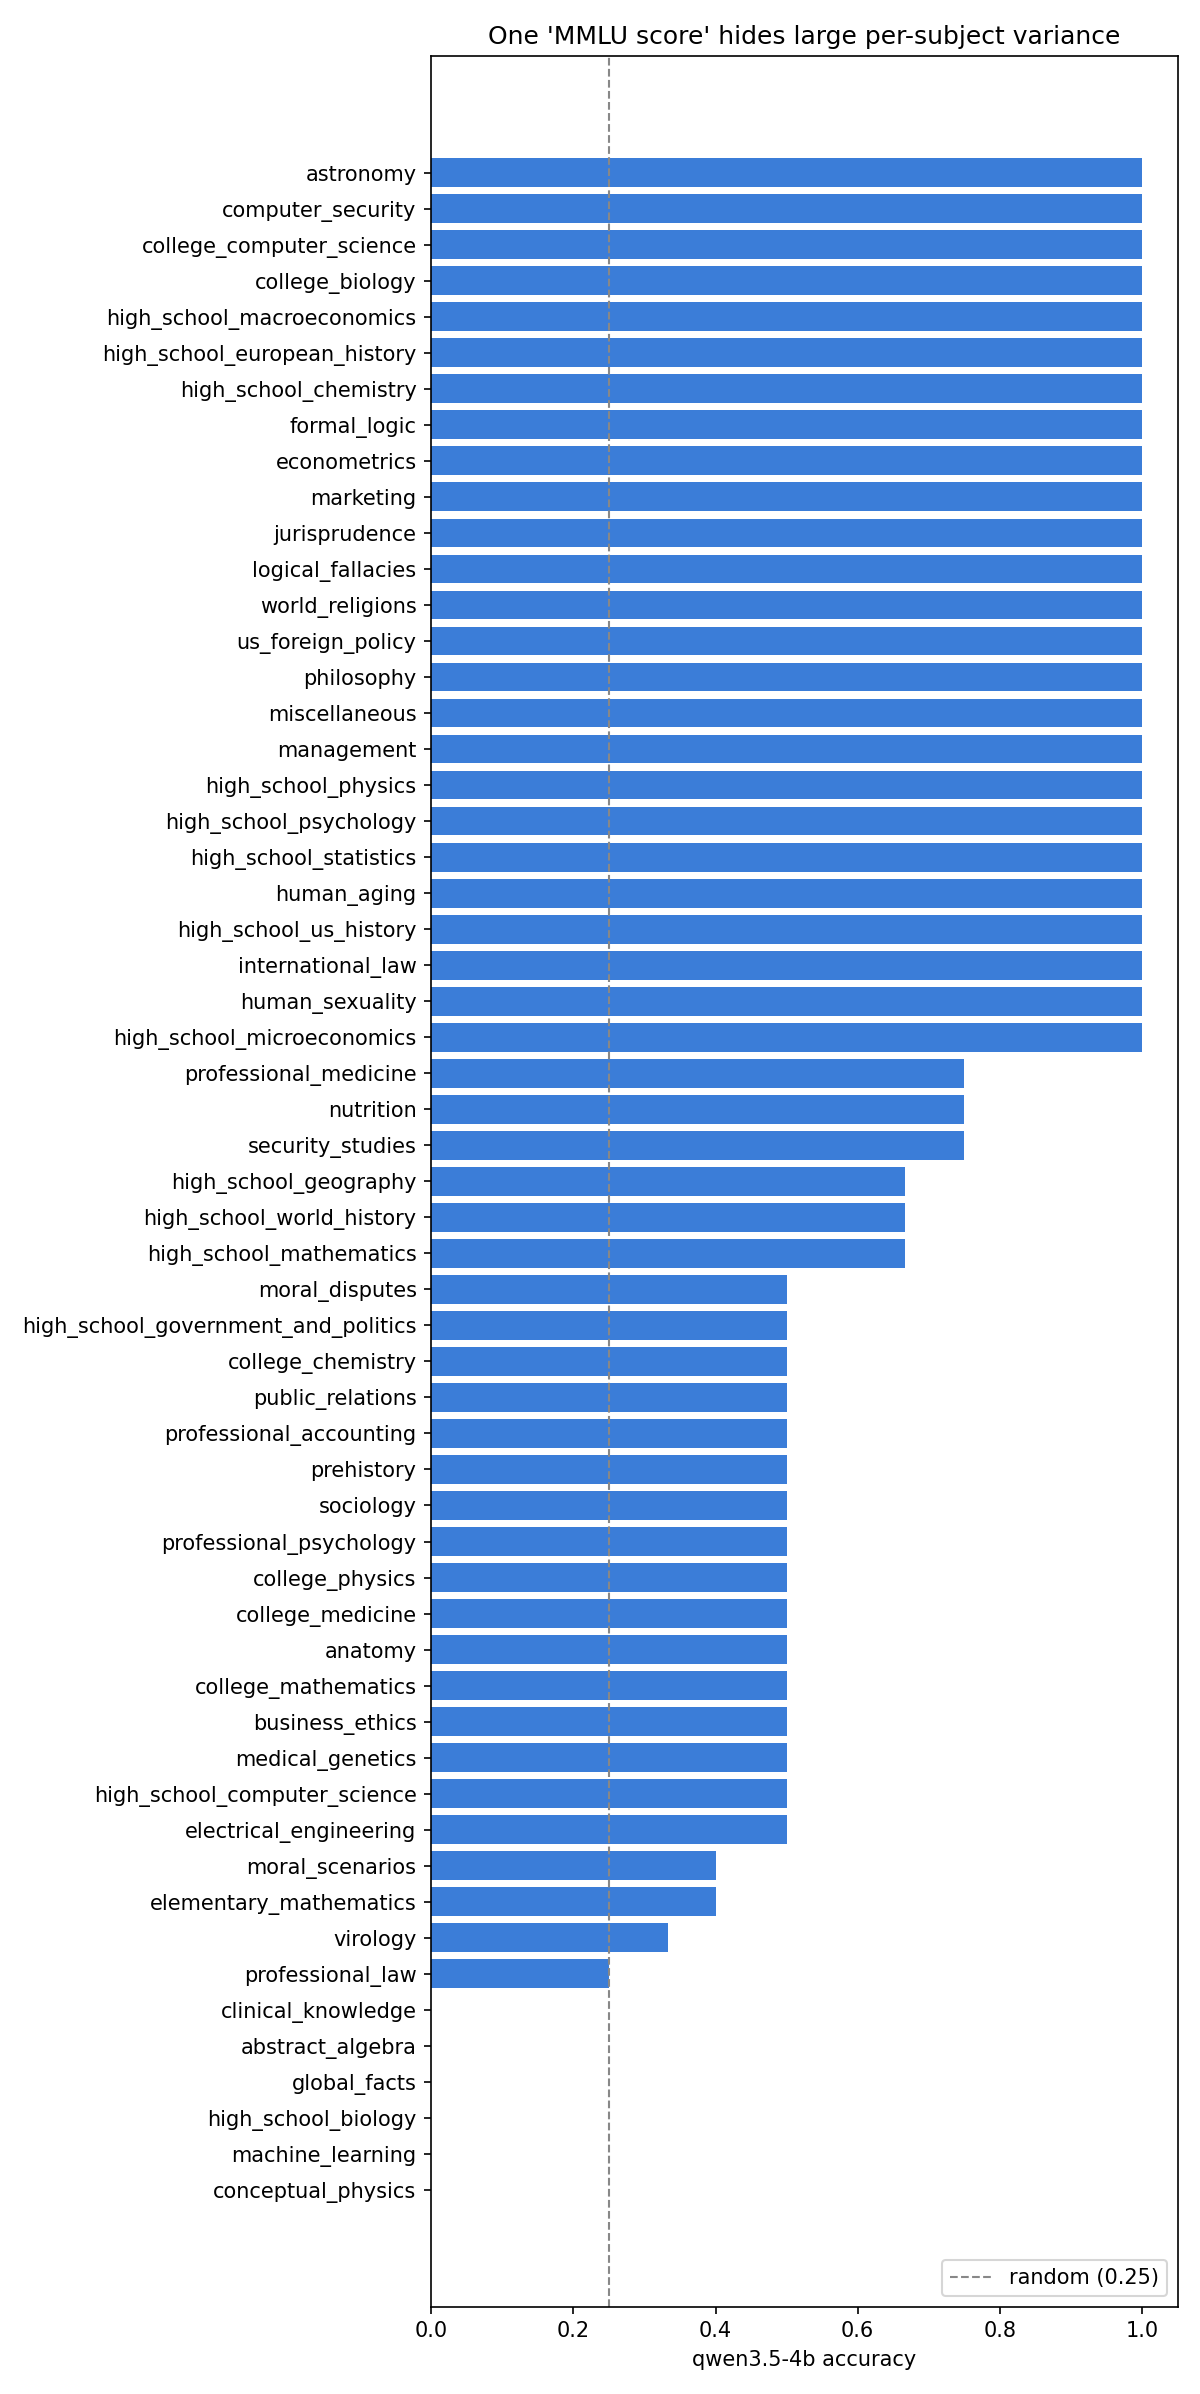

In [8]:
from IPython.display import Image, display
for fig in ["saturation", "model_agreement", "metric_gap", "robustness", "mmlu_by_subject"]:
    display(Image(f"results/figures/{fig}.png"))

In [9]:
# Depth views: ranking stability + extraction coverage + per-subject + metric-gap cases
import pandas as pd
print("Ranking on MMLU vs GSM8K (rank_shift>0 ⇒ the benchmark changes who wins):")
display(pd.read_csv("results/ranking.csv"))

print("\nAnswer-extraction coverage per model (low ⇒ penalised by format, not capability):")
display(pd.read_csv("results/coverage.csv"))

subj = pd.read_csv("results/mmlu_by_subject.csv")
print("\nMMLU per-subject — most and least solved:")
display(pd.concat([subj.head(8), subj.tail(8)]))

gap = pd.read_csv("results/metric_gap_examples.csv")
print(f"\nGSM8K right answers the naive (first-number) grader scored wrong: {len(gap)}")
display(gap.head(8))

Ranking on MMLU vs GSM8K (rank_shift>0 ⇒ the benchmark changes who wins):


,system,params_b,acc_mmlu,rank_mmlu,acc_gsm8k,rank_gsm8k,rank_shift
0,qwen3.5-4b,4.0,0.686667,1,0.9125,1,0
1,phi-3.5-mini,3.8,0.586667,2,0.8500,2,0
2,gemma-4-e4b,4.5,0.533333,3,0.7875,3,0
3,qwen2.5-3b,3.1,0.513333,4,0.7750,4,0
4,gemma-4-e2b,2.3,0.426667,5,0.7250,5,0



Answer-extraction coverage per model (low ⇒ penalised by format, not capability):


,system,benchmark,coverage,n
0,gemma-4-e2b,gsm8k,1.000,80
1,gemma-4-e4b,gsm8k,1.000,80
2,phi-3.5-mini,gsm8k,1.000,80
3,qwen2.5-3b,gsm8k,1.000,80
4,qwen3.5-4b,gsm8k,1.000,80
5,gemma-4-e2b,mmlu,0.965,200
6,gemma-4-e4b,mmlu,0.945,200
7,phi-3.5-mini,mmlu,0.990,200
8,qwen2.5-3b,mmlu,0.985,200
9,qwen3.5-4b,mmlu,0.985,200



MMLU per-subject — most and least solved:


,subject,n_items,gemma-4-e2b,gemma-4-e4b,phi-3.5-mini,qwen2.5-3b,qwen3.5-4b
0,astronomy,3,0.666667,0.666667,1.000000,0.333333,1.000000
1,college_computer_science,2,0.500000,0.500000,0.500000,0.500000,1.000000
2,college_biology,2,1.000000,1.000000,1.000000,1.000000,1.000000
3,high_school_macroeconomics,3,0.333333,1.000000,1.000000,1.000000,1.000000
4,high_school_european_history,2,0.500000,0.500000,0.500000,0.500000,1.000000
5,high_school_chemistry,3,0.333333,0.333333,0.666667,0.666667,1.000000
6,formal_logic,2,1.000000,0.000000,1.000000,1.000000,1.000000
7,econometrics,2,1.000000,0.000000,1.000000,0.500000,1.000000
49,virology,3,0.000000,0.333333,0.333333,0.000000,0.333333
50,professional_law,4,0.250000,0.250000,0.750000,0.250000,0.250000



GSM8K right answers the naive (first-number) grader scored wrong: 322


,system,id,gold,extracted,prediction
0,gemma-4-e2b,gsm8k_0000,100,100,**Reasoning:** ⏎ ⏎ 1. **Calculate the school'...
1,gemma-4-e2b,gsm8k_0001,30,30,Here is the step-by-step solution: ⏎ ⏎ **1. D...
2,gemma-4-e2b,gsm8k_0002,623,623,**Reasoning:** ⏎ ⏎ 1. **Calculate Alex's weig...
3,gemma-4-e2b,gsm8k_0004,10,10,"Let $S_1$, $S_2$, and $S_3$ be the number of t..."
4,gemma-4-e2b,gsm8k_0005,12,12,Here is the step-by-step solution: ⏎ ⏎ **Reas...
5,gemma-4-e2b,gsm8k_0007,3000,3000,Here is the step-by-step solution: ⏎ ⏎ **Reas...
6,gemma-4-e2b,gsm8k_0009,5,5,**Reasoning:** ⏎ Greg has a total of $\$20$ to...
7,gemma-4-e2b,gsm8k_0010,1200,1200,Here is the step-by-step solution: ⏎ ⏎ **Reas...


## 8. Save outputs
Everything under the cloned repo's `results/` is downloadable from the notebook's **Output** tab. Commit those CSVs + PNGs back to the repo to fill the README results tables.

In [10]:
import shutil
shutil.make_archive("/kaggle/working/results", "zip", "results")
print("zipped -> /kaggle/working/results.zip")

zipped -> /kaggle/working/results.zip
